In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt 
import seaborn as sns

In [24]:
df = pd.read_csv("income.csv")

In [25]:
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [26]:
scaler = MinMaxScaler(feature_range=(0,2))

In [27]:
df[['Age','Income($)']] = scaler.fit_transform(df[['Age','Income($)']])

In [28]:
df

,Name,Age,Income($)
0,Rob,0.117647,0.427350
1,Michael,0.352941,0.769231
2,Mohan,0.352941,0.273504
3,Ismail,0.235294,0.256410
4,Kory,1.882353,1.794872
5,Gautam,1.529412,1.880342
6,David,1.764706,1.965812
7,Andrea,1.411765,2.000000
8,Brad,1.176471,1.897436
9,Angelina,1.058824,1.452991


In [8]:
km = KMeans(n_clusters=3)

In [30]:
y_pred  = km.fit_predict(df[['Age','Income($)']])

In [31]:
y_pred

array([2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1],
      dtype=int32)

In [32]:
df['cluster'] = y_pred

In [33]:
df

,Name,Age,Income($),cluster
0,Rob,0.117647,0.427350,2
1,Michael,0.352941,0.769231,2
2,Mohan,0.352941,0.273504,2
3,Ismail,0.235294,0.256410,2
4,Kory,1.882353,1.794872,0
5,Gautam,1.529412,1.880342,0
6,David,1.764706,1.965812,0
7,Andrea,1.411765,2.000000,0
8,Brad,1.176471,1.897436,0
9,Angelina,1.058824,1.452991,0


C:\Users\laksh\AppData\Local\Temp\ipykernel_4332\2713451339.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


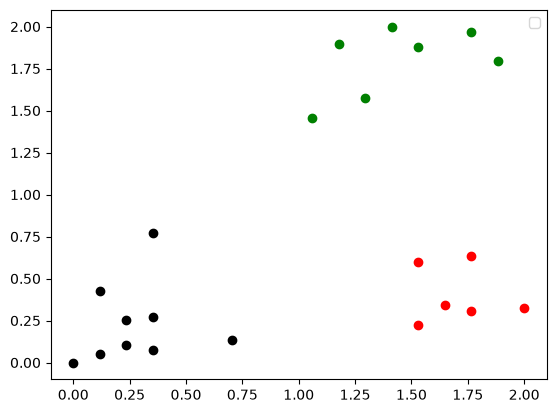

In [35]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]
plt.scatter(df1.Age,df1['Income($)'], color='green')
plt.scatter(df2.Age,df2['Income($)'],color='red')
plt.scatter(df3.Age,df3['Income($)'],color='black')
plt.legend()

In [36]:
km.cluster_centers_

array([[1.44537815, 1.79487179],
       [1.70588235, 0.4045584 ],
       [0.2745098 , 0.23266857]])

C:\Users\laksh\AppData\Local\Temp\ipykernel_4332\1753353619.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


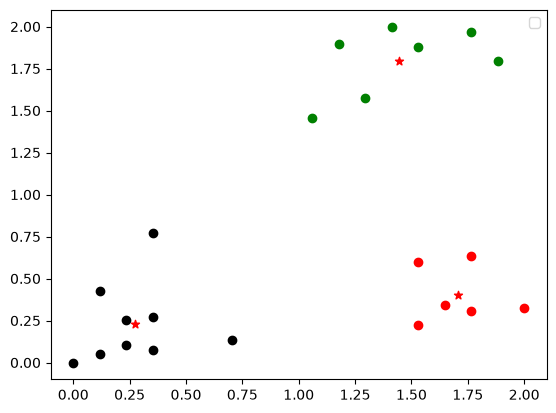

In [39]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]
plt.scatter(df1.Age,df1['Income($)'], color='green')
plt.scatter(df2.Age,df2['Income($)'],color='red')
plt.scatter(df3.Age,df3['Income($)'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],marker = '*',color ='red')
plt.legend()

In [41]:
k_range = range(1,10)
inertia = []
for k in k_range:
    km = KMeans(n_clusters=k)
    km.fit(df[['Age','Income($)']])
    inertia.append(km.inertia_)

In [42]:
inertia

[21.736046047952712,
 8.364545554796312,
 1.9003133994212384,
 1.5526116665914975,
 1.3790149973866301,
 0.842667139520421,
 0.9048556338393089,
 0.7239487872084803,
 0.44494202780956393]

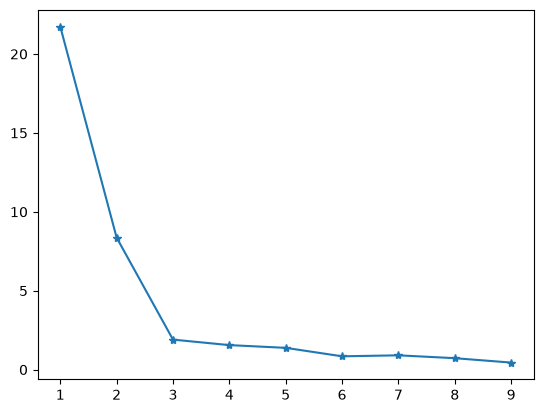

In [45]:
plt.plot(k_range,inertia,marker = '*')

THAT'S THE ELBOW CURVE